### Домашнє завдання: Пониження розмірностей для Аналізу Портретів Клієнтів

#### Контекст
В цьому ДЗ ми попрацюємо з методами пониження розмірності на наборі даних для задачі аналізу портретів клієнтів (Customer Personality Analysis). **В попередньому ДЗ ми працювали з цими даними використовуючи кластеризацію, зараз використаємо кластеризацію і візуалізауємо результати з різними методами.**

Customer Personality Analysis - це аналіз різних сегментів клієнтів компанії. Цей аналіз дозволяє бізнесу краще розуміти своїх клієнтів і полегшує процес адаптації продуктів під конкретні потреби, поведінку та інтереси різних типів клієнтів.

Аналіз портретів клієнтів допомагає бізнесу змінювати свій продукт на основі цільової аудиторії, розділеної на різні сегменти. Наприклад, замість того, щоб витрачати гроші на маркетинг нового продукту для всіх клієнтів у базі даних компанії, бізнес може проаналізувати, який сегмент клієнтів найімовірніше придбає продукт, і потім зосередити маркетингові зусилля лише на цьому сегменті.

#### Вхідні дані
Вам надано набір даних з такими атрибутами:

**Характеристики користувачів:**
- `ID`: Унікальний ідентифікатор клієнта
- `Year_Birth`: Рік народження клієнта
- `Education`: Рівень освіти клієнта
- `Marital_Status`: Сімейний стан клієнта
- `Income`: Річний дохід домогосподарства клієнта
- `Kidhome`: Кількість дітей у домогосподарстві клієнта
- `Teenhome`: Кількість підлітків у домогосподарстві клієнта
- `Dt_Customer`: Дата реєстрації клієнта у компанії
- `Recency`: Кількість днів з моменту останньої покупки клієнта
- `Complain`: 1, якщо клієнт скаржився за останні 2 роки, 0 - якщо ні

**Продукти:**
- `MntWines`: Сума, витрачена на вино за останні 2 роки
- `MntFruits`: Сума, витрачена на фрукти за останні 2 роки
- `MntMeatProducts`: Сума, витрачена на м'ясні продукти за останні 2 роки
- `MntFishProducts`: Сума, витрачена на рибні продукти за останні 2 роки
- `MntSweetProducts`: Сума, витрачена на солодощі за останні 2 роки
- `MntGoldProds`: Сума, витрачена на золото за останні 2 роки

**Акції:**
- `NumDealsPurchases`: Кількість покупок, зроблених з використанням знижок
- `AcceptedCmp1`: 1, якщо клієнт прийняв пропозицію у першій кампанії, 0 - якщо ні
- `AcceptedCmp2`: 1, якщо клієнт прийняв пропозицію у другій кампанії, 0 - якщо ні
- `AcceptedCmp3`: 1, якщо клієнт прийняв пропозицію у третій кампанії, 0 - якщо ні
- `AcceptedCmp4`: 1, якщо клієнт прийняв пропозицію у четвертій кампанії, 0 - якщо ні
- `AcceptedCmp5`: 1, якщо клієнт прийняв пропозицію у п'ятій кампанії, 0 - якщо ні
- `Response`: 1, якщо клієнт прийняв пропозицію в останній кампанії, 0 - якщо ні

**Взаємодія з компанією:**
- `NumWebPurchases`: Кількість покупок, зроблених через вебсайт компанії
- `NumCatalogPurchases`: Кількість покупок, зроблених за каталогом
- `NumStorePurchases`: Кількість покупок, зроблених безпосередньо у магазинах
- `NumWebVisitsMonth`: Кількість відвідувань вебсайту компанії за останній місяць


Для початку, запустіть код нижче. Всі ці кроки ми робили в попередньому ДЗ і для того, щоб результати кластеризації у нас були схожими, потрібно аби передобробка була однаковою.

In [2]:
import pandas as pd

# 1. Завантаження даних
df = pd.read_csv('../../Sample Data/marketing_campaign.csv', sep="\t")

# 2. Обробка пропущених значень
df['Income_not_filled'] = df.Income.isna()
df.Income = df.Income.fillna(-1)

# 3. Обробка дати реєстрації
df.Dt_Customer = pd.to_datetime(df.Dt_Customer, format='%d-%m-%Y')
today = df.Dt_Customer.max()
df['days_lifetime'] = (today - df.Dt_Customer).dt.days
df['years_customer'] = df.Year_Birth.apply(lambda x: today.year - x)

# 4. Категоризація рівня освіти
df_education = pd.get_dummies(df.Education, prefix='education').astype(int)
df = pd.concat([df, df_education], axis=1)

# 5. Очищення сімейного стану
marital_status_map = {'Alone': 'Single', 'Absurd': 'Else', 'YOLO': 'Else'}
df['Marital_Status_clean'] = df.Marital_Status.map(marital_status_map)
df_ms = pd.get_dummies(df.Marital_Status_clean, prefix='marital').astype(int)
df = pd.concat([df, df_ms], axis=1)

# 6. Форматування доходу і видалення викиду
df.Income = df.Income.astype(int)
df = df[df.Income != 666666]

# 7. Створення фінального набору даних
X = df.drop(['ID', 'Dt_Customer', 'Education', 'Marital_Status', 'Marital_Status_clean'], axis=1)
X.reset_index(drop=True, inplace=True)

### Завдання 1: Виконання кластеризації та пониження розмірності для візуалізації результатів

Ваше завдання — провести кластеризацію клієнтів та візуалізувати результати кластеризації, використовуючи метод головних компонент (PCA) для пониження розмірності даних.

#### Інструкції:

1. **Вибір ключових характеристик:**
   Давайте обмежимось тільки наступними хараткеристиками для кластеризації цього разу:
   - `Income`: Річний дохід домогосподарства клієнта
   - `Recency`: Кількість днів з моменту останньої покупки клієнта
   - `NumStorePurchases`: Кількість покупок, зроблених безпосередньо у магазинах
   - `NumDealsPurchases`: Кількість покупок, зроблених з використанням знижок
   - `days_lifetime`: Кількість днів з моменту реєстрації клієнта у компанії
   - `years_customer`: Вік клієнта
   - `NumWebVisitsMonth`: Кількість відвідувань вебсайту компанії за останній місяць
   Відберіть в наборі даних `X` лише ці характеристики.

2. **Стандартизація даних:**
   Використайте метод `StandardScaler` для стандартизації значень обраних характеристик.
   
   **Чому не MinMaxScaler:**
   - Для PCA краще використовувати StandardScaler, бо він вирівнює дисперсію ознак, на відміну від MinMaxScaler, що просто масштабує значення без врахування варіації.

   - Для K-Means також краще використовувати StandardScaler, бо алгоритм чутливий до масштабів: фічі з більшими значеннями сильніше впливають на обчислення відстаней, що може спотворити кластери.

3. **Кластеризація:**
   Проведіть кластеризацію клієнтів, використовуючи метод `KMeans` з трьома кластерами.

4. **Пониження розмірності:**
   Використайте метод головних компонент (PCA) для пониження розмірності даних до трьох компонент.

5. **Візуалізація результатів:**
   Використовуючи plolty express побудуйте 3D-графік розподілу клієнтів у просторі трьох головних компонент, де кольором позначено кластери.

6. **Опишіть, що спостерігаєте:**
   Чи кластеризація чітко розділила дані?

Далі ми детальніше проінтерпретуємо результати візуалізації і пониження розмірностей.

In [3]:
cols = [
    'Income',
    'Recency',
    'NumStorePurchases',
    'NumDealsPurchases',
    'days_lifetime',
    'years_customer',
    'NumWebVisitsMonth'
]

X = X[cols].copy()

In [4]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns, index=X.index)

In [23]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, n_init='auto')
kmeans.fit(X_scaled_df)

labels = kmeans.predict(X_scaled_df)

In [6]:
from sklearn.decomposition import PCA

pca = PCA(n_components=3, random_state = 0)
pca_bank = pca.fit(X_scaled_df)
pca_bank

,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",3
,"random_state random_state: int, RandomState instance or None, default=NoneUsed when the 'arpack' or 'randomized' solvers are used. Pass an intfor reproducible results across multiple function calls.See :term:`Glossary <random_state>`... versionadded:: 0.18.0",0
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ens

In [7]:
import plotly.express as px

pca_coordinates = pca_bank.transform(X_scaled_df)
df = pd.DataFrame(
    pca_coordinates,
    columns=['PC1', 'PC2', 'PC3'],
    index=X_scaled_df.index
)
df['Cluster'] = labels

fig = px.scatter_3d(
    df,
    x='PC1',
    y='PC2',
    z='PC3',
    color='Cluster',
    title='3D PCA Visualization of Customer Clusters'
)

fig.show()

Перші три головні компоненти пояснюють 65.85% загальної дисперсії даних. Найбільшу частку дисперсії пояснює PC1 — 31.85%, далі PC2 — 19.66% і PC3 — 14.34%. Таким чином, PCA зменшує кількість ознак до трьох компонент, зберігаючи приблизно дві третини варіативності даних. Решта 34.15% дисперсії припадає на компоненти PC4–PC7, які не були включені.

На 3D-графіку видно певне розділення кластерів, однак вони частково перетинаються, тому не можна говорити про повністю чітке розділення. Значення 65.85% є помірним, тому для збереження більшої кількості інформації можна використати більше головних компонент.

### Завдання 2: Аналіз результатів пониження розмірності

1. **Розрахунок частки поясненої дисперсії:**
   Визначте, яка частка загальної варіації даних пояснюється кожною з трьох головних компонент (PC1, PC2, PC3) за допомогою атрибуту `explained_variance_ratio_` об'єкта PCA. Виведіть результат на екран.

2. **Розрахунок кумулятивної частки поясненої дисперсії:**
   Обчисліть кумулятивну частку поясненої дисперсії для трьох головних компонент, щоб зрозуміти, скільки варіації даних пояснюється першими кількома компонентами.

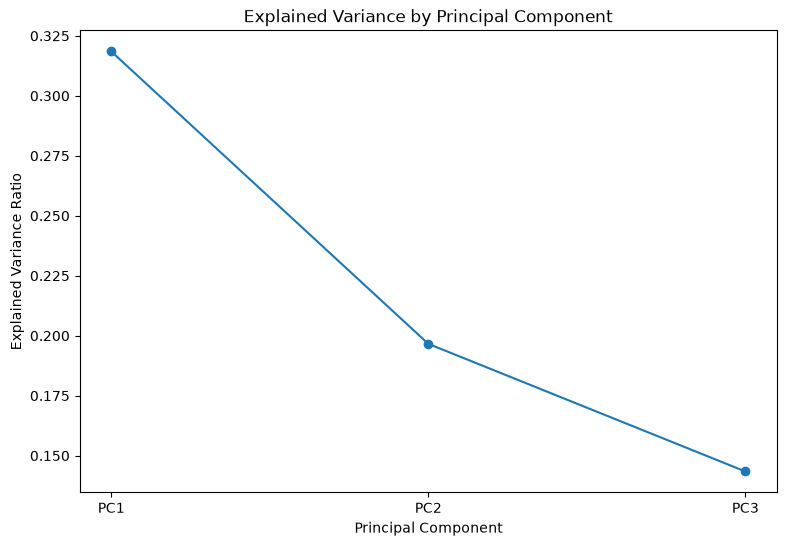

array([0.31847333, 0.19659128, 0.1433869 ])

In [8]:
import matplotlib.pyplot as plt
import numpy as np

explained_variance = pca_bank.explained_variance_ratio_
components = ['PC1', 'PC2', 'PC3']

plt.figure(figsize=(9, 6))
plt.plot(components, explained_variance, marker='o')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('Explained Variance by Principal Component')
plt.show()

explained_variance

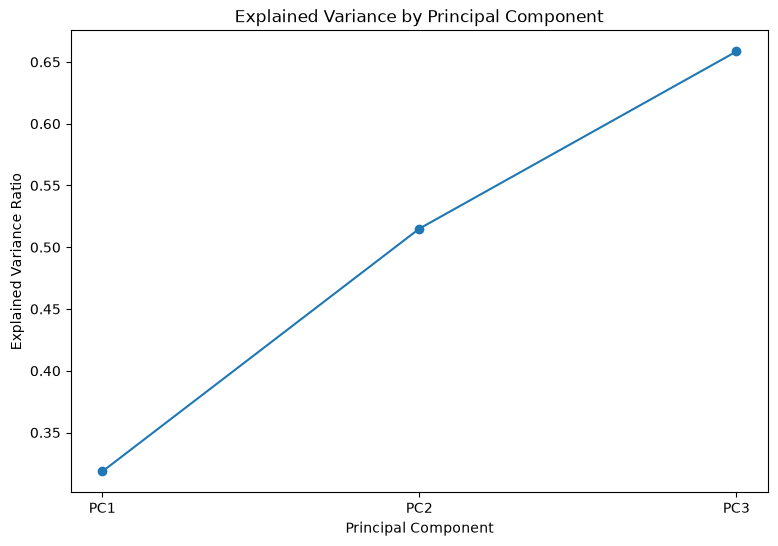

array([0.31847333, 0.51506461, 0.6584515 ])

In [9]:
cumsum_explained_variance = np.cumsum(pca_bank.explained_variance_ratio_)
components = ['PC1', 'PC2', 'PC3']

plt.figure(figsize=(9, 6))
plt.plot(components, cumsum_explained_variance, marker='o')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('Explained Variance by Principal Component')
plt.show()

cumsum_explained_variance

### Завдання 3: Інтерпретація "Loadings"

Продовжуємо інтерпретацію результатів `PCA`і познайомимось з новим поняттям `loadings`, яке допоможе нам знайти звʼязок між головними компонентами і оригінальними ознаками в наборі даних.

Ми зараз побудували візуалізацію кластерів точок даних в просторі трьох головних компонент. Але хочеться знайти звʼязок між головними компонентами і оригінальними ознаками. Для розуміння, які початкові характеристики даних мають найбільший вплив на ці головні компоненти, ми можемо використати атрибут `components_` методу `PCA`.

#### Що таке `pca.components_`?

`pca.components_` — це масив, який містить коефіцієнти (або "ваги"), що показують внесок кожної вихідної ознаки у кожну з головних компонент. Ці коефіцієнти ще називаються **"loading"** або "навантаженнями" компонент.

- **Loadings** (`навантаження`) відображають важливість кожної змінної (ознаки) для відповідної головної компоненти. Вони показують, яким чином змінні поєднуються, щоб утворити нові, зменшені вимірювання.
- Якщо коефіцієнт має високе абсолютне значення (як позитивне, так і негативне), це вказує на те, що відповідна змінна сильно впливає на головну компоненту.

#### Саме завдання
Ваше завдання — обчислити "навантаження" для кожної з головних компонент і інтерпретувати результати.

1. **Обчислення loadings для компонент:**
   Використайте атрибут `components_` об'єкта PCA для створення DataFrame, який відображатиме внесок кожної вихідної ознаки в кожну головну компоненту.

2. **Інтерпретація результатів:**
   Виведіть значення "навантажень" і проаналізуйте, які ознаки найбільше впливають на кожну головну компоненту.

In [10]:
loadings = pd.DataFrame(
    pca.components_.T,
    columns=['PC1', 'PC2', 'PC3'],
    index=X_scaled_df.columns
)

loadings.style.background_gradient(cmap='Blues').format('{:.3f}')

,PC1,PC2,PC3
Income,0.584,0.165,-0.044
Recency,0.010,0.037,0.976
NumStorePurchases,0.489,0.385,-0.081
NumDealsPurchases,-0.199,0.608,-0.035
days_lifetime,-0.133,0.603,-0.022
years_customer,0.189,0.209,0.193
NumWebVisitsMonth,-0.572,0.216,-0.016


За результатами аналізу навантажень найбільший вплив на **PC1** має ознака `Income` з коефіцієнтом 0.584. Також `NumStorePurchases` (0.489) і `NumWebVisitsMonth` (-0.572). Це означає, що PC1 переважно пов'язана з доходом і купівельною активністю клієнтів, а негативний коефіцієнт `NumWebVisitsMonth` вказує на протилежний напрямок впливу.

Для **PC2** найбільші навантаження мають `NumDealsPurchases` (0.608) і `days_lifetime` (0.603). Отже, ця компонента характеризує схильність клієнтів купувати зі знижками та тривалість їхньої взаємодії з компанією.

**PC3** майже повністю визначається ознакою `Recency`, яка має найбільше за модулем навантаження (0.976). Тому PC3 переважно описує давність останньої покупки клієнта.

### Завдання 4
Давайте проаналізуємо "навантаження" (**loadings**) для трьох головних компонент після вилучення ознаки `Income`. Це допоможе нам зрозуміти, як змінилася важливість інших ознак для кожної головної компоненти, коли одна з ключових характеристик (`Income`) була вилучена.

#### Кроки для проведення аналізу і ваше завдання:

1. Видаліть ознаку `Income` з нашого набору даних `X` і повторно виконайте PCA (метод головних компонент) для отримання нових "навантажень".

2. Обчисліть нові "навантаження" для трьох головних компонент на наборі даних без `Income`

3. Проаналізуйте, які ознаки мають найбільший вплив на кожну головну компоненту після вилучення `Income`.

4. Перегляньте, наскільки кожна з головних компонент пояснює дисперсію в даних без ознаки `Income`.

In [11]:
X_scaled_without_income_df = X_scaled_df.drop(
    columns=['Income']
)

pca_without_income = PCA(n_components=3, random_state=0)
pca_without_income.fit(X_scaled_without_income_df)

loadings_without_income = pd.DataFrame(
    pca_without_income.components_.T,
    columns=['PC1', 'PC2', 'PC3'],
    index=X_scaled_without_income_df.columns
)

loadings_without_income.style.background_gradient(
    cmap='Blues'
).format('{:.3f}')

,PC1,PC2,PC3
Recency,-0.014,0.075,0.990
NumStorePurchases,-0.381,0.629,-0.111
NumDealsPurchases,0.446,0.462,-0.062
days_lifetime,0.384,0.468,0.007
years_customer,-0.177,0.394,0.056
NumWebVisitsMonth,0.691,-0.108,0.010


Після вилучення ознаки `Income` структура головних компонент змінилася. Найбільший вплив на PC1 має `NumWebVisitsMonth`, на PC2 — `NumStorePurchases`, а PC3 майже повністю визначається ознакою `Recency`. Отже, без доходу PCA більше відображає активність клієнтів, кількість покупок і давність останньої покупки.

In [12]:
pca_without_income.explained_variance_ratio_

array([0.27392228, 0.21444861, 0.16684415])

Після вилучення ознаки Income перші три головні компоненти пояснюють 65.52% загальної дисперсії даних. Це значення майже не змінилося порівняно з моделлю, у якій Income була присутня: дисперсія зменшилася лише з 65.85% до 65.52%. Найбільшу частку дисперсії пояснює PC1 — 27.39%, далі PC2 — 21.44% і PC3 — 16.68%. Отже, три компоненти досить добре описують дані навіть без ознаки доходу, хоча приблизно 34.48% дисперсії залишається в наступних компонентах.

### Завдання 5: Візуалізація кластеризації за допомогою t-SNE

Ваше завдання — використати метод t-SNE для візуалізації результатів кластеризації клієнтів у двовимірному просторі. Метод t-SNE допомагає знизити розмірність даних та зберегти локальні структури в даних, що робить його ефективним для візуалізації високорозмірних даних. Ми також зможемо порівняти результат цього методу з РСА.

1. Використайте метод t-SNE для зниження розмірності до 2х вимірів даних, які включають ознаки всі, що і в завданні 1, а також були відмасштабовані перед пониженням розмірностей.

2. Створіть новий DataFrame з координатами, отриманими після застосування t-SNE, та додайте до нього мітки кластерів.

3. Побудуйте інтерактивний 2D-графік розподілу клієнтів, де кольором буде позначено різні кластери і проаналізуйте графік з рекомендаціями нижче (можливо треба буде вивести додаткові візуалізації чи таблиці для інтерпретації, але треба прям зрозуміти, які ознаки формують який кластер і чим кластери відрізняються одне від одного).

  **Опишіть отримані кластери з точки зору ознак.**

4. Опишіть відмінність графіка tSNE від PCA.

#### ЯК можна інтерпретувати з t-SNE?

Хоча t-SNE не надає "компонентів" як РСА, він забезпечує низьковимірне представлення даних, яке можна візуально інтерпретувати:

- **Кластери:** t-SNE особливо добре показує кластери подібних точок. Якщо ви бачите чітко визначені кластери на графіку t-SNE, це свідчить про наявність груп схожих спостережень у ваших даних. Проаналізувати їх можемо, якщо додамо дані в `hover_data` або якщо якісь з даних виведемо як розмір чи форма точок на візуалізації. Також корисно може бути вивести середні значення ознак по кластерам.
- **Локальна структура:** Відносне розташування точок одного кластеру на графіку t-SNE може допомогти вам зрозуміти, які дані подібні між собою.
- **Глобальна структура:** Будьте обережні; t-SNE менш надійний для відображення глобальних структур (наприклад, відстаней між кластерами) у порівнянні з PCA, бо t-SNE націлений на збереження саме локальних структур.

In [30]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, random_state=0)
tsne_coordinates = tsne.fit_transform(X_scaled_df)

In [31]:
tsne_df = pd.DataFrame(
    tsne_coordinates,
    columns=['t-SNE 1', 't-SNE 2'],
    index=X_scaled_df.index
)
tsne_df['Cluster'] = labels

tsne_df = pd.concat([tsne_df, X.reset_index(drop=True)], axis=1)
tsne_df.head()

,t-SNE 1,t-SNE 2,Cluster,Income,Recency,NumStorePurchases,NumDealsPurchases,days_lifetime,years_customer,NumWebVisitsMonth
0,-6.063711,18.885963,2,58138,58,4,3,663,57,7
1,-1.191696,-33.018177,1,46344,38,2,2,113,60,5
2,30.209709,-1.151231,0,71613,26,10,1,312,49,4
3,-49.576939,-28.636620,1,26646,26,4,2,139,30,6
4,-10.096333,37.193043,2,58293,94,6,5,161,33,5


In [32]:
cluster_profile = (
    X.assign(Cluster=labels)
    .groupby('Cluster')[cols]
    .agg(['mean', 'median'])
    .round(2)
)

cluster_sizes = (
    pd.Series(labels, name='Clients')
    .value_counts()
    .sort_index()
    .to_frame()
)

print('Кількість клієнтів у кластерах:')
display(cluster_sizes)
print('Середні та медіанні значення ознак за кластерами:')
display(cluster_profile)

Кількість клієнтів у кластерах:


,count
Clients,
0,823
1,962
2,454


Середні та медіанні значення ознак за кластерами:


Income          Recency        NumStorePurchases         \
             mean   median    mean median              mean median   
Cluster                                                              
0        72551.55  72025.0   49.35   50.0              8.34    8.0   
1        33077.67  33459.0   48.48   48.0              3.18    3.0   
2        51943.98  52801.0   50.08   51.5              6.71    6.0   

        NumDealsPurchases        days_lifetime        years_customer         \
                     mean median          mean median           mean median   
Cluster                                                                       
0                    1.44    1.0        315.25  293.0          47.35   47.0   
1                    1.81    2.0        312.27  297.5          41.93   41.0   
2                    5.00    5.0        510.52  543.0          48.23   48.0   

        NumWebVisitsMonth         
                     mean median  
Cluster                           
0                    3.07    3.0  
1                    6.51    7.0  
2                    6.87    7.0

In [34]:
fig = px.scatter(
    tsne_df,
    x='t-SNE 1',
    y='t-SNE 2',
    color='Cluster',
    hover_data=cols,
    title='t-SNE: клієнти за кластерами KMeans',
    labels={'Cluster': 'Кластер'},
    template='plotly_white'
)
fig.update_traces(marker={'size': 7, 'opacity': 0.75})
fig.update_layout(
    legend_title_text='Кластер',
    width=1000,
    height=550
)
fig.show()

### Інтерпретація кластерів і порівняння графіків PCA та t-SNE

Профіль кластерів показує таку сегментацію:

- **Кластер 0 (823 клієнти):** найвищий середній дохід — 72 551.55, найбільше покупок у магазині — 8.34, найменше відвідувань сайту — 3.07 і найменше покупок зі знижками — 1.44. Це клієнти з високою купівельною спроможністю, які частіше купують у магазині та менше залежать від промоакцій.
- **Кластер 1 (962 клієнти):** найнижчий дохід — 33 077.67, найменше покупок у магазині — 3.18, найбільше відвідувань сайту — 6.51. Це менш активні в покупках клієнти з нижчим доходом, які частіше взаємодіють з онлайн-каналом.
- **Кластер 2 (454 клієнти):** середній дохід — 51 943.98, 6.71 покупки у магазині, але найбільше покупок зі знижками — 5.00 і найбільше відвідувань сайту — 6.87. Це клієнти, чутливі до акцій: вони активні онлайн і частіше використовують угоди.

Середні значення `Recency` для кластерів близькі (приблизно 48–50 днів), тому ця ознака майже не розділяє групи. Відмінності між кластерами переважно формують `Income`, `NumStorePurchases`, `NumDealsPurchases` і `NumWebVisitsMonth`. Номери кластерів є умовними: перестановка номерів не змінює самі групи.

**Відмінність графіків PCA та t-SNE.** На 3D-графіку PCA кластери розташовані в просторі трьох головних компонент і частково перекриваються. Точки одного кластера не завжди утворюють компактну область, проте на графіку можна бачити загальний напрямок розподілу даних, а осі PC1, PC2 і PC3 мають фіксований зміст.

На 2D-графіку t-SNE точки схожих клієнтів зазвичай утворюють більш компактні локальні групи, тому межі між кластерами можуть виглядати чіткішими. Водночас осі `t-SNE 1` і `t-SNE 2` не мають змістовної інтерпретації. Отже, PCA-графік краще показує загальну геометрію розподілу, а t-SNE-графік — локальну схожість клієнтів і компактність кластерів.